In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Processing

## Loading Files

In [2]:
def string_to_tuple(tuple_string):
    return (int(tuple_string[0]), int(tuple_string[1]))

def pattern_string_to_tuple_list(pattern_string):
    return sorted([string_to_tuple(s) for s in [c.replace('[', '').replace(';','').replace(']','').replace(',','') for c in pattern_string.split(' ')]])

def patterns_from_txt(filepath) -> list[list[tuple[int,int]]]:
    patterns = []
    with open(filepath, 'r') as file:
        lines = file.readlines()
        for line in lines:
            patterns.append(pattern_string_to_tuple_list(line))
    return patterns

Load all stats.csv files into their respective dataframes, load pattern int tuple lists

In [3]:
CURRENT_SERIES = 'A'
CURRENT_PATH = f'tests_{CURRENT_SERIES}/'
BATCHES = ['30_1', '15_2', '15_3', '15_4', '10_1', '10_2', '10_3']

In [4]:
ind_dataframes:dict[pd.DataFrame] = {}
pattern_list:list[tuple[int,int]] = patterns_from_txt(f'{CURRENT_PATH}patterns_{CURRENT_SERIES}.txt')

for batch in BATCHES:
    ind_dataframes[batch] = pd.read_csv(f'{CURRENT_PATH}stats_{batch}.csv')


In [5]:
# pattern_dicts: list[dict[int,list[tuple[int,int]]]] = []
# for i in range(N_TOTAL_BATCHES):
#     pattern_dicts.append(dict())
#     for i_p, pattern in enumerate(pattern_lists):
#         pattern_dicts[i][i_p] = pattern

Create new "processed" dataframes 

In [6]:
for batch in BATCHES:
    ind_dataframes[batch]['original_pattern'] = [pattern_string_to_tuple_list(s) for s in ind_dataframes[batch]['original_pattern']]
    ind_dataframes[batch]['OP_i'] = [pattern_list.index(s) for s in ind_dataframes[batch]['original_pattern']]

for each batch: create dict where index -> sucess rate

# Data Analysis

for batches 1, 2, 5: plot success rate for each pattern in function of index

In [7]:
success_dicts: dict[dict[int,float]] = {}
interference_dicts: dict[dict[int,float]] = {}

for batch in BATCHES:
    success_dicts[batch] = dict()
    interference_dicts[batch] = dict()
    for i_pattern in range(20):
        current_slice_df = ind_dataframes[batch][ind_dataframes[batch]['OP_i'] == i_pattern]
        success_dicts[batch][i_pattern] = len(current_slice_df[current_slice_df['reconstr_success'] == True]) / len(current_slice_df)
        if 'others_silent' in current_slice_df:
            interference_dicts[batch][i_pattern] = len(current_slice_df[current_slice_df['others_silent'] == True]) / len(current_slice_df)

In [8]:
vir = plt.colormaps['viridis']

def plot_pattern_success(batches):
    for i, b in enumerate(batches):
        plt.plot(range(20), [success_dicts[b][i_p] for i_p in range(20)], label=f'Batch {b}', marker='x', alpha=0.7, c=vir(i/len(batches)))
        # if len(interference_dicts[b]) > 0:
        #     plt.plot(range(20), [interference_dicts[b][i_p] for i_p in range(20)], marker='o', alpha=0.4, c=vir(i/len(batches)))
    plt.xlabel('Pattern index (/ training order)')
    plt.xticks(np.arange(0, 20, 1))
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.ylabel('Reconstruction success (%)')
    plt.legend()
    plt.show()

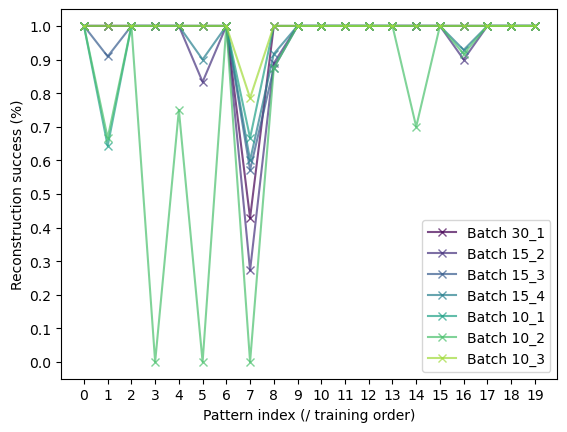

In [9]:
# %matplotlib qt
# % matplotlib inline
plot_pattern_success(BATCHES)

for each batch: print batch total success rate

In [10]:
for batch in BATCHES:
    total_success_rate = len(ind_dataframes[batch][ind_dataframes[batch]['reconstr_success'] == True]) / len(ind_dataframes[batch])
    print(f'Average reconstruction success rate for batch {batch} = {round(total_success_rate*100,2)}%')
    total_interf_rate = len(ind_dataframes[batch][ind_dataframes[batch]['others_silent'] == False]) / len(ind_dataframes[batch])
    print(f'Average interference rate for batch {batch} = {round(total_interf_rate*100,2)}%')

Average reconstruction success rate for batch 30_1 = 98.0%
Average interference rate for batch 30_1 = 21.0%
Average reconstruction success rate for batch 15_2 = 94.06%
Average interference rate for batch 15_2 = 41.09%
Average reconstruction success rate for batch 15_3 = 97.51%
Average interference rate for batch 15_3 = 33.33%
Average reconstruction success rate for batch 15_4 = 96.52%
Average interference rate for batch 15_4 = 18.91%
Average reconstruction success rate for batch 10_1 = 96.52%
Average interference rate for batch 10_1 = 35.32%
Average reconstruction success rate for batch 10_2 = 75.12%
Average interference rate for batch 10_2 = 44.78%
Average reconstruction success rate for batch 10_3 = 98.51%
Average interference rate for batch 10_3 = 21.89%
